In [17]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
df_bass = pd.read_csv('examples_csv/tekonivel_onsets_bass.csv')
display(df_bass)

df_hum = pd.read_csv('examples_csv/tekonivel_onsets_hum.csv')
display(df_hum)

df_bdrum = pd.read_csv('examples_csv/tekonivel_onsets_bdrum.csv')
display(df_bdrum)


,TIME,LABEL
0,0.691156,1.1
1,1.246259,1.2
2,1.804989,1.3
3,2.360091,1.4
4,2.915193,2.1
5,3.475737,2.2
6,4.032653,2.3
7,4.584127,2.4
8,5.146485,3.1
9,5.705215,3.2


,TIME,LABEL
0,2.371338,5.1
1,4.165079,5.2
2,5.950113,5.3
3,7.726440,5.4
4,9.512925,6.1
5,11.283447,6.2
6,13.017687,6.3


,TIME,LABEL
0,9.585488,New Point
1,10.033560,6.4
2,10.476190,7.1
3,10.926077,7.2
4,11.366893,7.3
5,11.814966,7.4
6,12.255782,8.1
7,12.703855,8.2
8,13.150113,8.3
9,13.592744,8.4


In [18]:
import numpy as np

def compute_ioi_stats(df, col='TIME'):
    onsets = df[col].to_numpy()
    ioi = np.diff(onsets)
    n_ioi = ioi.size              # total number of intervals
    return {
        'count_ioi': n_ioi,
        'min': np.min(ioi),
        'max': np.max(ioi),
        'range': np.ptp(ioi),
        'mean': np.mean(ioi)
    }

datasets = {
    'Bass': df_bass,
    'Hum': df_hum,
    'BDrum': df_bdrum
}

for name, df in datasets.items():
    stats = compute_ioi_stats(df)
    print(f"=== {name} Onset IOI stats ===")
    print(f"Count of IOI values: {stats['count_ioi']}")
    print(f"Min   = {stats['min']:.6f}")
    print(f"Max   = {stats['max']:.6f}")
    print(f"Range = {stats['range']:.6f}")
    print(f"Mean  = {stats['mean']:.6f}")
    print()


=== Bass Onset IOI stats ===
Count of IOI values: 15
Min   = 0.547846
Max   = 0.564172
Range = 0.016327
Mean  = 0.556553

=== Hum Onset IOI stats ===
Count of IOI values: 6
Min   = 1.734240
Max   = 1.793741
Range = 0.059501
Mean  = 1.774392

=== BDrum Onset IOI stats ===
Count of IOI values: 13
Min   = 0.440816
Max   = 0.449887
Range = 0.009070
Mean  = 0.445561



In [35]:
# Define the grid size in seconds
grid = 0.1114

# A list to store the new DataFrames for each instrument
all_ioi_dfs = []

for name, df in datasets.items():
    # Step 1: Calculate the IOIs
    onsets = df['TIME'].to_numpy()
    iois = np.diff(onsets)

    # Step 2: Calculate the multiplier for each IOI
    # We divide the IOI by the grid size and round to the nearest integer.
    multipliers = np.round(iois / grid).astype(int)

    # Step 3: Calculate the error for each IOI
    # Error = | Actual IOI - (Multiplier * Grid) |
    errors = np.abs(iois - (multipliers * grid))

    # Step 4: Create a new DataFrame for the current instrument
    ioi_df = pd.DataFrame({
        'IOI': iois,
        'Multiplier': multipliers,
        'Error': errors
    })
    
    # Add an 'Instrument' column to identify the source
    ioi_df['Instrument'] = name
    
    all_ioi_dfs.append(ioi_df)

# Step 5: Concatenate all the individual DataFrames into a single one
final_df = pd.concat(all_ioi_dfs, ignore_index=True)

# Reorder columns for better readability
final_df = final_df[['Instrument', 'IOI', 'Multiplier', 'Error']]

# Display the final DataFrame
display(final_df)

# You can also display statistics for the new columns
print("\n--- Error Statistics per Instrument ---")
display(final_df.groupby('Instrument')['Error'].describe())

,Instrument,IOI,Multiplier,Error
0,Bass,0.555102,5,0.001898
1,Bass,0.558730,5,0.001730
2,Bass,0.555102,5,0.001898
3,Bass,0.555102,5,0.001898
4,Bass,0.560544,5,0.003544
5,Bass,0.556916,5,0.000084
6,Bass,0.551474,5,0.005526
7,Bass,0.562358,5,0.005358
8,Bass,0.558730,5,0.001730
9,Bass,0.556916,5,0.000084



--- Error Statistics per Instrument ---


,count,mean,std,min,25%,50%,75%,max
Instrument,,,,,,,,
BDrum,13.0,0.002524,0.001473,0.000659,0.001156,0.002473,0.002970,0.004784
Bass,15.0,0.003282,0.002575,0.000084,0.001730,0.001898,0.004535,0.009154
Hum,6.0,0.014029,0.017139,0.002634,0.004582,0.008707,0.011744,0.048160


In [20]:
import numpy as np

# Assuming 'datasets' is the dictionary of your DataFrames from the original question
# datasets = {
#     'Bass': df_bass,
#     'Hum': df_hum,
#     'BDrum': df_bdrum
# }

cue_lists_np = {name: df['TIME'].to_numpy() for name, df in datasets.items()}

# Now you can access each cue list as a NumPy array
bass_onsets_np = cue_lists_np['Bass']
bdrum_onsets_np = cue_lists_np['BDrum']
hum_onsets_np = cue_lists_np['Hum']

# You can verify the type
print(f"Type of bass_onsets_np: {type(bass_onsets_np)}")
print(f"First 5 onsets for Bass: {bass_onsets_np[:5]}")

Type of bass_onsets_np: <class 'numpy.ndarray'>
First 5 onsets for Bass: [0.69115646 1.2462585  1.80498866 2.3600907  2.91519274]


In [34]:
import numpy as np
import random
from typing import Union, List, Optional

from py_scripts.onset_generator import generate_onset_pattern
from py_scripts.audio_visualizer import load_audio, extract_features, visualize_features

generated_onsets = generate_onset_pattern(
    pattern=0.55655,
    start_time=0.6911,        
    num_events=50,
    tolerance=None 
)

generated_onsets2 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.02 
)

generated_onsets3 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.05 
)


# Structure them into the dictionary for plotting
onset_times_dict = {
    "Bass": {
        "times": bass_onsets_np,
        "color": "red",
    },
    "Hum": {
        "times": hum_onsets_np,
        "color": "orange",
    },
    "BDrum": {
        "times": bdrum_onsets_np,
        "color": "cyan",
    }
    # "Generated Onsets": {
    #     "times": generated_onsets,
    #     "color": "cyan",
    # }
}

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---

# --- CONFIGURATION ---
AUDIO_PATH = 'examples_audio/Tekonivel_Voimamies.aif'
HOP_LENGTH = 128
N_FFT = 2048

TIME_RANGE = "00:00.000-00:15.500" 

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH, time_range=TIME_RANGE)

# 2. Define which features you want to compute and plot

# Features: 'waveform', 'stft_db', 'amplitude_envelope', 'zero_crossing_rate', 
# 'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
# 'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'

FEATURES_TO_PLOT = ['waveform', 'melspectrogram', 'amplitude_envelope', 'zero_crossing_rate', 
'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
'rms_low', 'rms_mid', 'rms_high', 'phase_flux']

# 3. COMPUTE THE FEATURES from the audio signal
# This will return a dictionary like {'waveform': [...], 'stft_db': [...], ...}
feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)

# Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'bokeh'

# Plot them!
visualize_features(
    features=feature_data,              
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND
)

Loading BokehJS ...

Loaded 'examples_audio/Tekonivel_Voimamies.aif' -> segment 0.000–15.500s of 201.024s @ 44100Hz


In [16]:
print(generated_onsets)

[ 0.6911   1.24765  1.8042   2.36075  2.9173   3.47385  4.0304   4.58695
  5.1435   5.70005  6.2566   6.81315  7.3697   7.92625  8.4828   9.03935
  9.5959  10.15245 10.709   11.26555 11.8221  12.37865 12.9352  13.49175
 14.0483  14.60485 15.1614  15.71795 16.2745  16.83105 17.3876  17.94415]


In [17]:
import pandas as pd

df1 = pd.read_csv('examples_csv/dufour_manual.csv')
display(df1)

df2 = pd.read_csv('examples_csv/dufour_onsets_librosa_filtered.csv')
display(df2)


,peaks_in_sec
0,0.398730
1,2.623492
2,4.863492
3,7.080635
4,9.340952
5,11.553016
6,13.782857
7,16.017778
8,18.245079
9,20.490159


,seq1
0,0.400544
1,2.618050
2,4.858776
3,7.082086
4,9.322812
5,11.528707
6,13.775238
7,16.015964
8,18.210249
9,20.485805


In [18]:
onset_times1 = df1['peaks_in_sec'].tolist()
print(onset_times1)

onset_times2 = df2['seq1'].tolist()
print(onset_times2)

[0.398730159, 2.623492063, 4.863492063, 7.080634921, 9.340952381, 11.553015873, 13.782857143, 16.017777778, 18.245079365, 20.49015873, 22.70984127, 24.954920635, 27.182222222, 29.424761905, 31.641904762, 33.881904762, 36.12952381, 38.38984127, 40.604444444, 42.852063492, 45.074285714, 47.311746032, 49.536507937, 51.781587302, 53.998730159, 56.236190476, 58.466031746, 60.693333333, 62.938412698, 65.158095238, 67.408253968, 69.627936508]
[0.4005442176870748, 2.618049886621315, 4.858775510204081, 7.082086167800454, 9.32281179138322, 11.528707482993198, 13.775238095238096, 16.015963718820863, 18.210249433106576, 20.48580498866213, 22.709115646258503, 24.9556462585034, 27.17315192743764, 29.41968253968254, 31.642993197278912, 33.88952380952381, 36.11283446712018, 38.376780045351474, 40.600090702947846, 42.84081632653061, 45.06993197278912, 47.31065759637188, 49.533968253968254, 51.78049886621315, 53.9980045351474, 56.24453514739229, 58.46784580498866, 60.67374149659864, 62.93768707482993, 6

In [19]:


# The new data structure for our functions
cue_lists = {
    "Manual Ground Truth": onset_times1,
    # "Librosa Onsets": onset_times2,
    "Generated Onsets, tol=0.01": generated_onsets,
    "Generated Onsets 2, tol=0.02": generated_onsets2,
    "Generated Onsets 3, tol=0.05": generated_onsets3
}

# The key for the reference list
ground_truth_key = "Manual Ground Truth" 

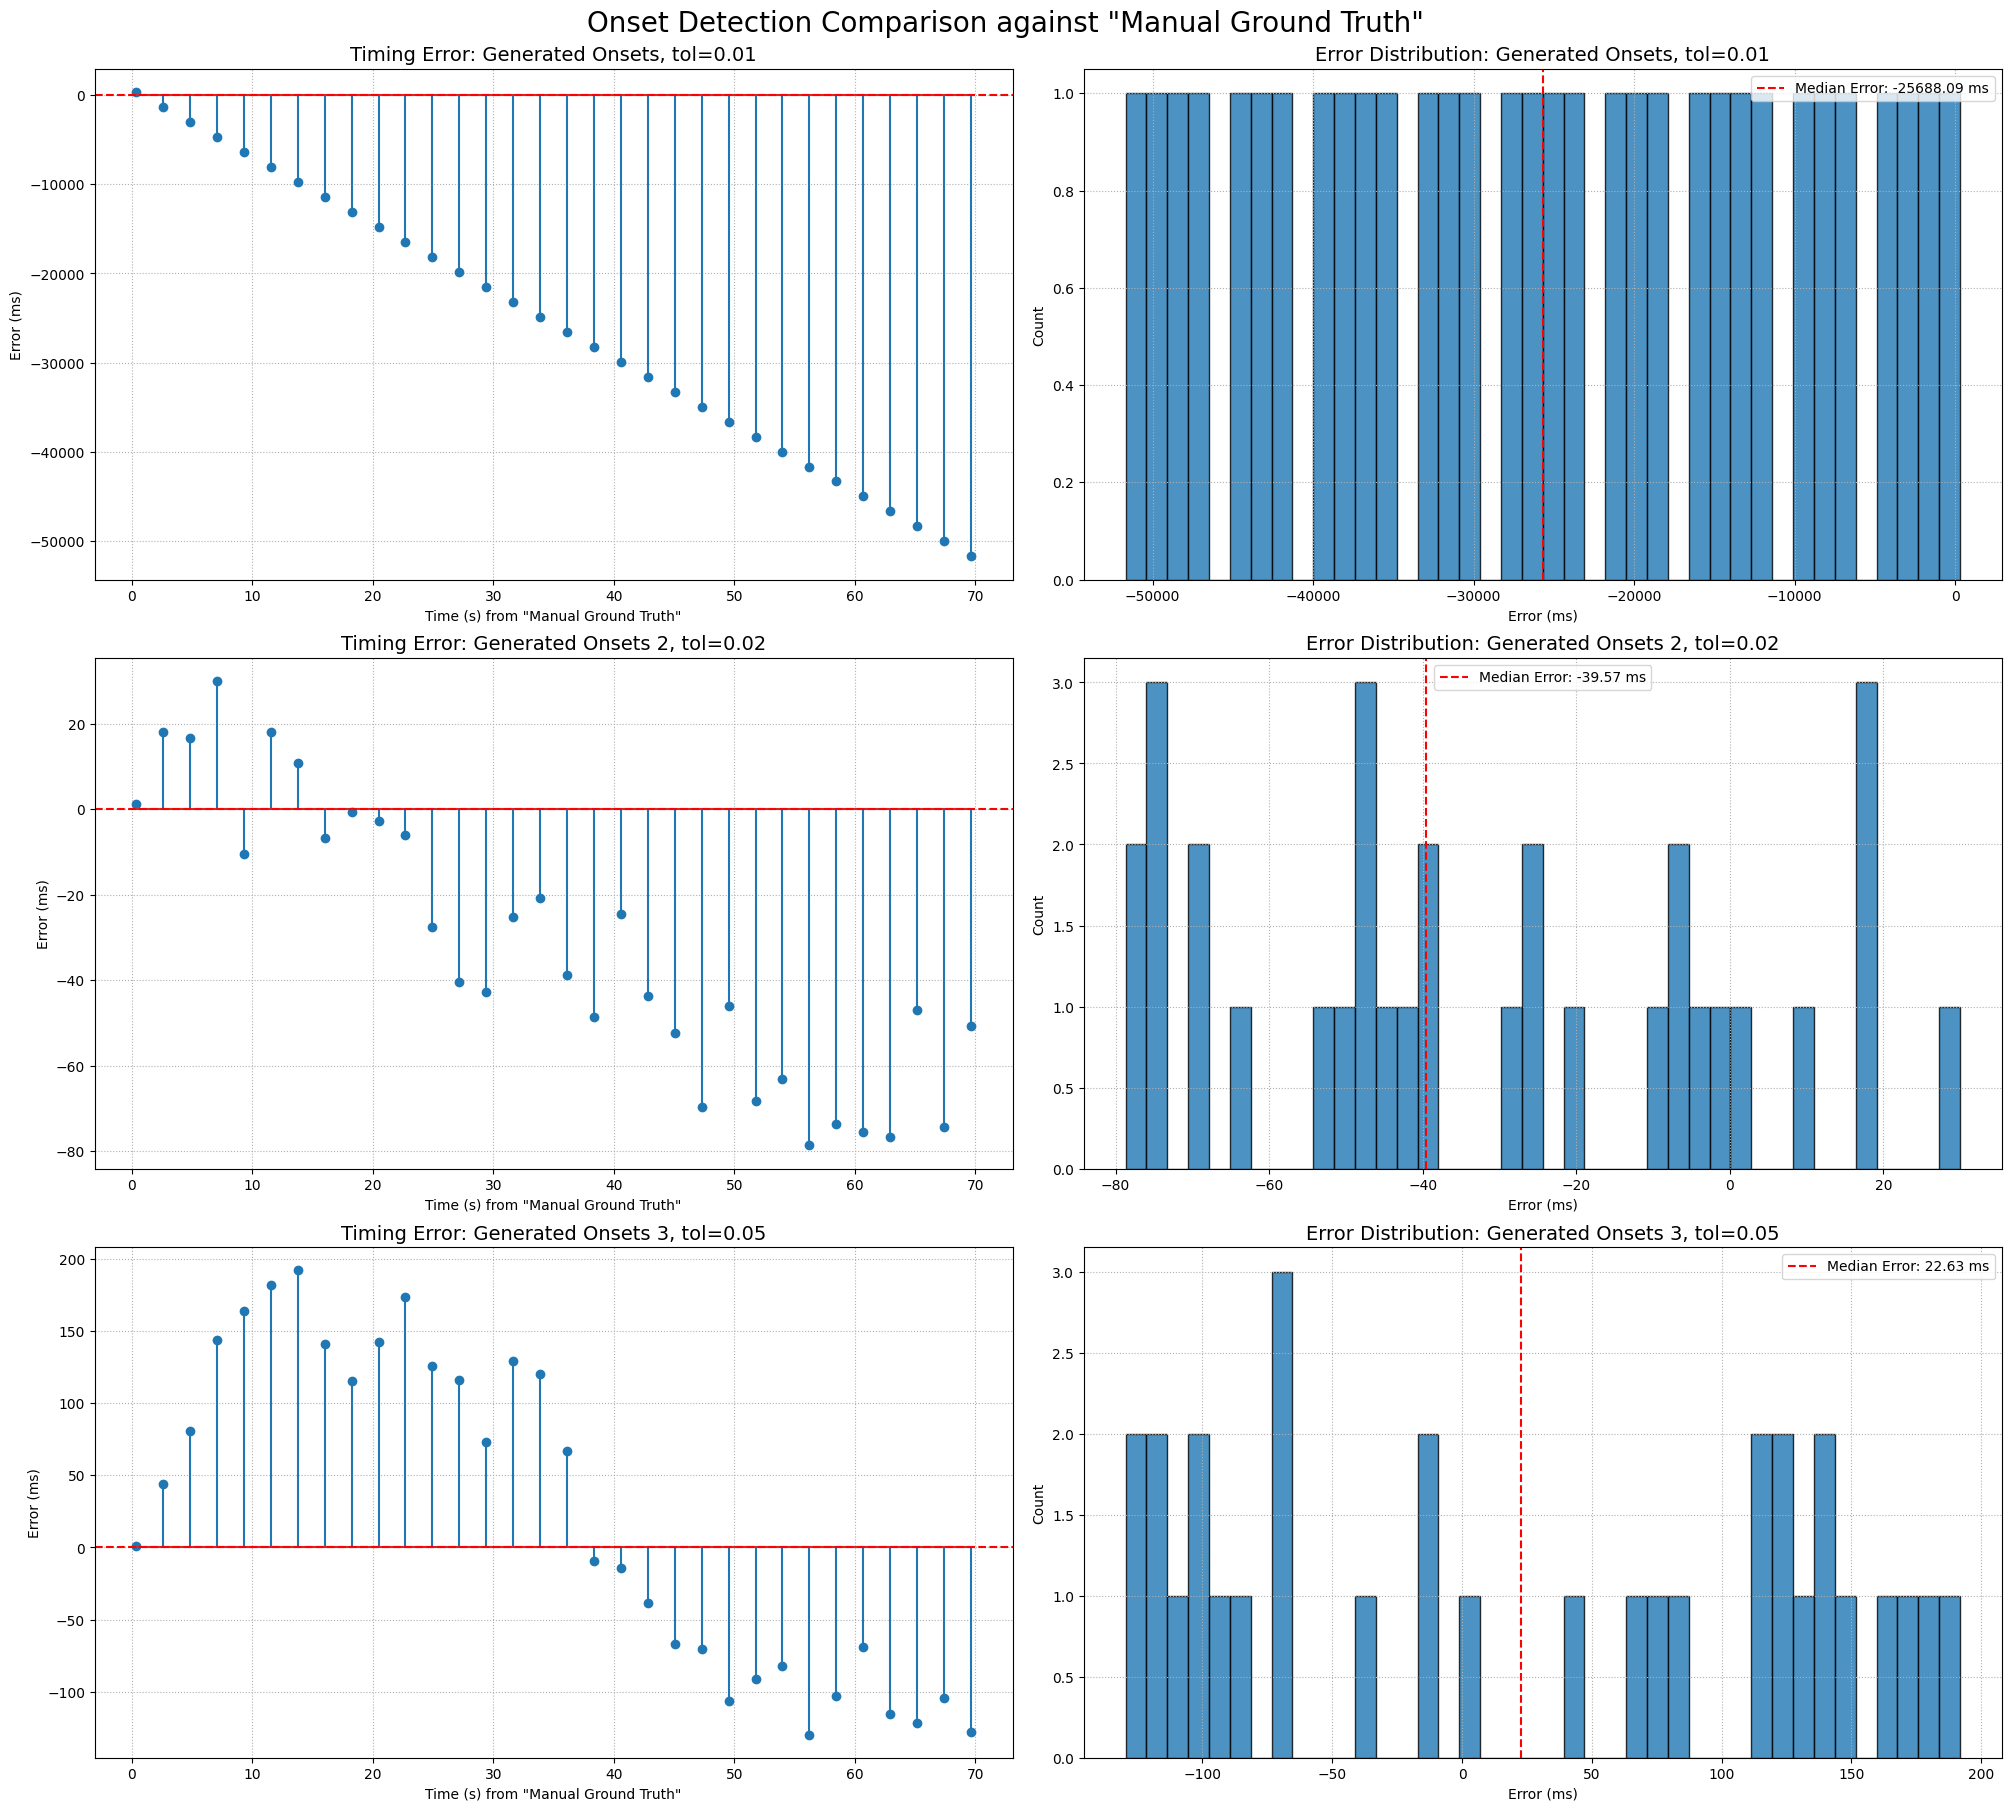

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List

def visualize_multi_onset_differences(
    cue_lists: Dict[str, List[float]], 
    ground_truth_key: str
):
    """
    Creates a dashboard to compare multiple detected onset lists against a single ground truth,
    using constrained_layout for robust spacing.
    """
    if ground_truth_key not in cue_lists:
        raise ValueError(f"The ground_truth_key '{ground_truth_key}' was not found in the cue_lists dictionary.")

    truth_times = np.array(cue_lists[ground_truth_key])
    detected_keys = [key for key in cue_lists if key != ground_truth_key]
    
    if not detected_keys:
        print("No other lists to compare against the ground truth.")
        return

    n_rows = len(detected_keys)
    
    # --- The key change is enabling constrained_layout=True here ---
    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 6 * n_rows), 
                             squeeze=False, constrained_layout=True)
                             
    fig.suptitle(f'Onset Detection Comparison against "{ground_truth_key}"', fontsize=20)

    for i, key in enumerate(detected_keys):
        # ... (The rest of the plotting logic inside the loop is identical) ...
        detected_times = np.array(cue_lists[key])
        min_len = min(len(truth_times), len(detected_times))
        truth_sliced = truth_times[:min_len]
        detected_sliced = detected_times[:min_len]
        error_ms = (detected_sliced - truth_sliced) * 1000

        # Plot 1: Timing Error
        ax1 = axes[i, 0]
        ax1.stem(truth_sliced, error_ms)
        ax1.axhline(0, color='r', linestyle='--')
        ax1.set_title(f'Timing Error: {key}', fontsize=14)
        ax1.set_xlabel(f'Time (s) from "{ground_truth_key}"')
        ax1.set_ylabel('Error (ms)')
        ax1.grid(True, linestyle=':')

        # Plot 2: Histogram
        ax2 = axes[i, 1]
        ax2.hist(error_ms, bins=40, alpha=0.8, edgecolor='black')
        median_error = np.median(error_ms)
        ax2.axvline(median_error, color='r', linestyle='--', label=f'Median Error: {median_error:.2f} ms')
        ax2.set_title(f'Error Distribution: {key}', fontsize=14)
        ax2.set_xlabel('Error (ms)')
        ax2.set_ylabel('Count')
        ax2.legend()
        ax2.grid(True, linestyle=':')

    # --- The old tight_layout() call is removed ---
    plt.show()

# --- HOW TO USE ---
visualize_multi_onset_differences(cue_lists, ground_truth_key)

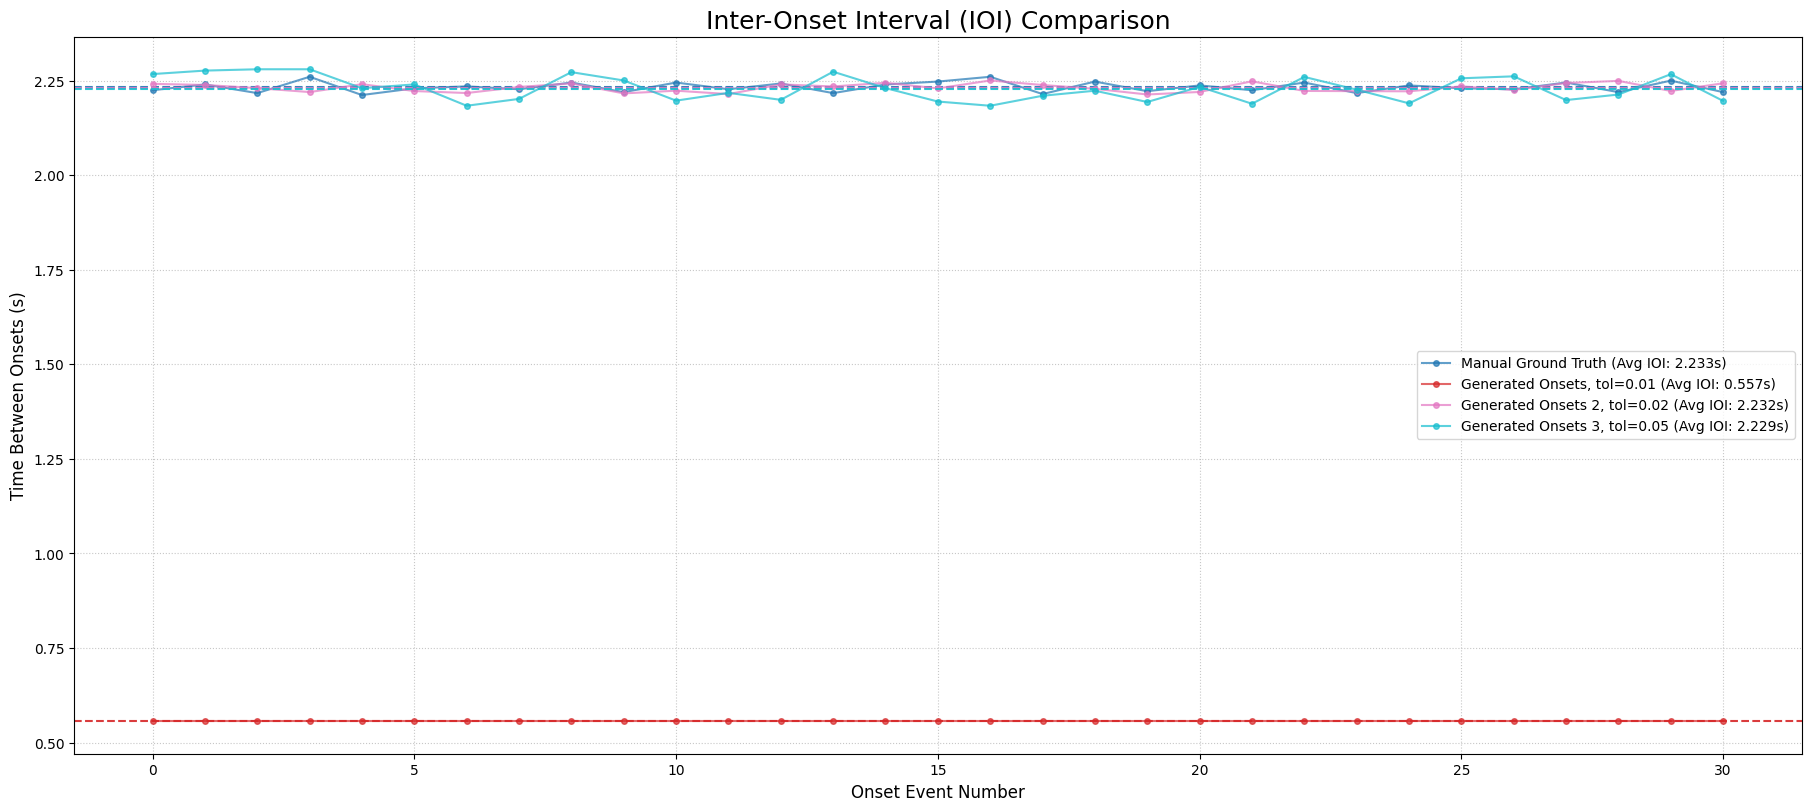

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_multi_ioi_comparison(cue_lists: Dict[str, List[float]]):
    """
    Calculates and plots the Inter-Onset Intervals (IOI) for multiple lists,
    using constrained_layout for robust legend placement.
    """
    # The key change is creating the figure and axes with constrained_layout=True
    fig, ax = plt.subplots(figsize=(18, 8), constrained_layout=True)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(cue_lists)))

    for i, (label, times) in enumerate(cue_lists.items()):
        if len(times) < 2:
            print(f"Warning: List '{label}' has fewer than 2 onsets, cannot calculate IOI. Skipping.")
            continue
            
        ioi = np.diff(np.array(times))
        avg_ioi = np.mean(ioi)
        legend_label = f'{label} (Avg IOI: {avg_ioi:.3f}s)'
        
        ax.plot(ioi, marker='o', linestyle='-', markersize=4, 
                label=legend_label, color=colors[i], alpha=0.7)
        ax.axhline(y=avg_ioi, color=colors[i], linestyle='--', alpha=0.9)

    ax.set_title('Inter-Onset Interval (IOI) Comparison', fontsize=18)
    ax.set_xlabel('Onset Event Number', fontsize=12)
    ax.set_ylabel('Time Between Onsets (s)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # A simple legend call is now sufficient. constrained_layout will make room for it.
    ax.legend()
    
    # We no longer need the plt.tight_layout() call.
    plt.show()

# --- HOW TO USE ---
plot_multi_ioi_comparison(cue_lists)

In [22]:
# Save selected sequence as CSV

import os

# 1. Define the filename
filename = "best_sequence.csv"

# 2. Save the array to the CSV file
np.savetxt(filename, generated_onsets3, delimiter=",")

# 3. Get the full, absolute path of the file
full_path = os.path.abspath(filename)

# 4. Print the confirmation message with the full path
print(f"The best sequence has been saved to: {full_path}")

The best sequence has been saved to: c:\Users\egorp\Nextcloud\code\public_repos\beat_it\best_sequence.csv


In [23]:
onset_times_dict = {
    "manual": {
        "times": onset_times1,
        "color": "red"
    },
    "librosa": {
        "times": onset_times2,
        "color": "magenta"
    }
}

Loading BokehJS ...

Loaded 'examples_audio/Dufour_full_mono.aif' -> 77.667s @ 44100Hz


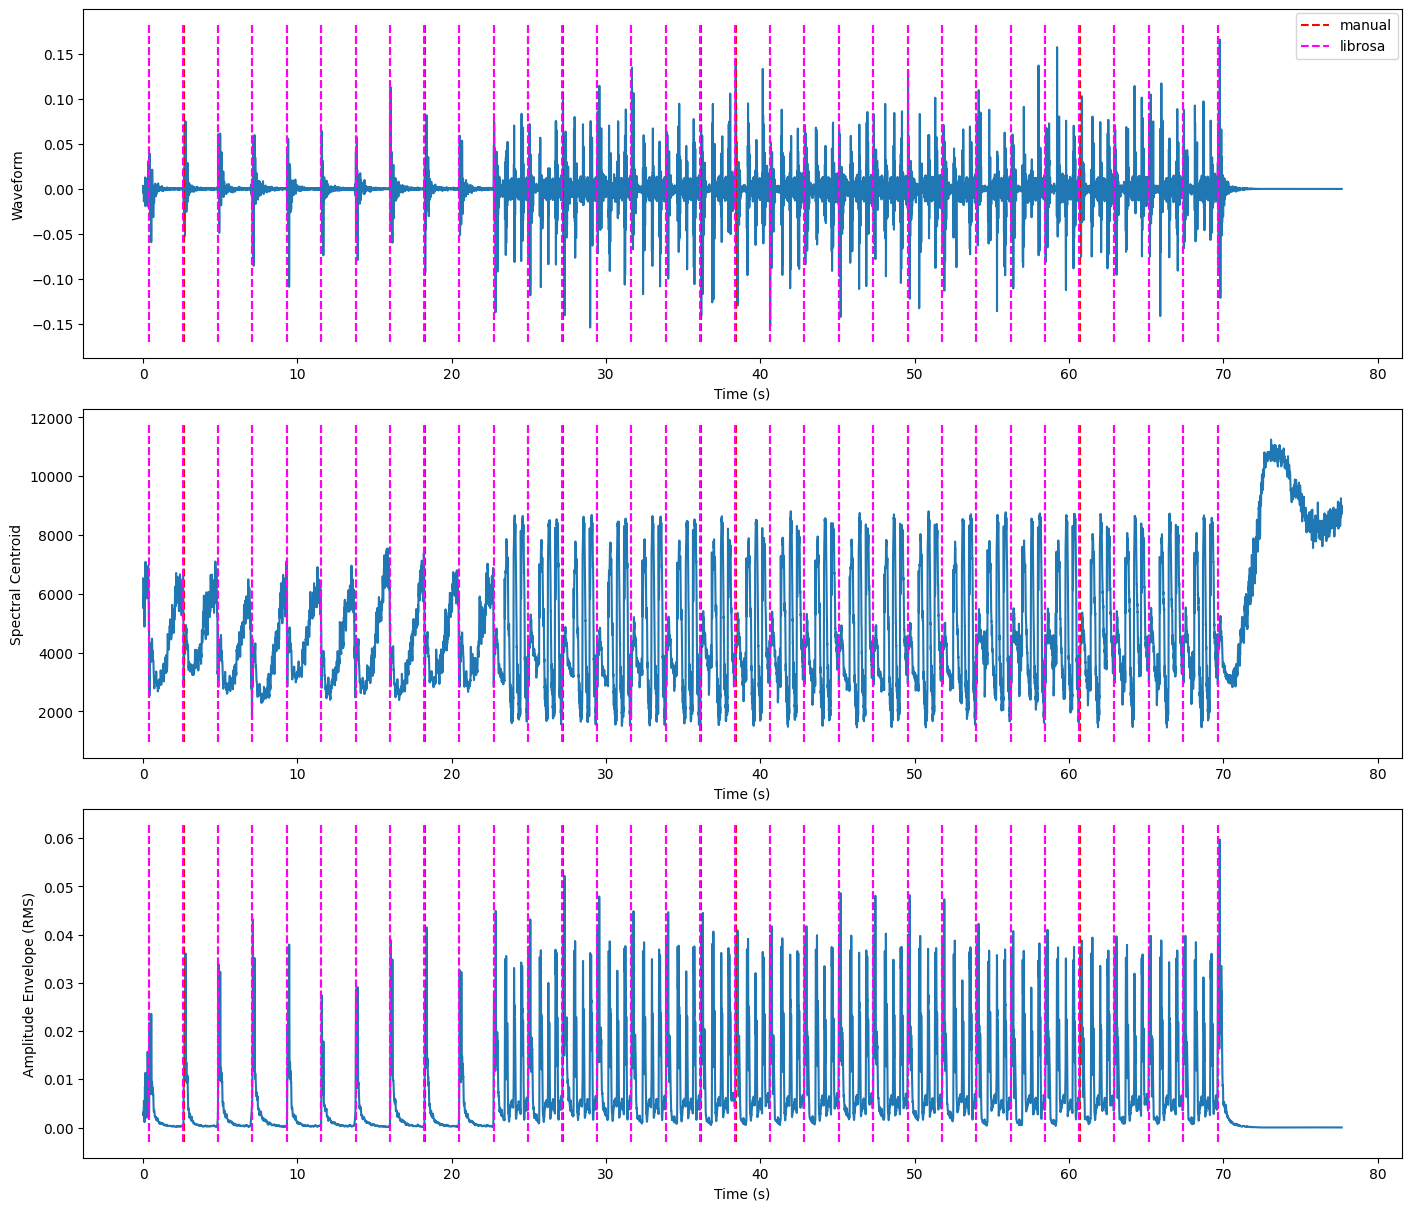

In [24]:
# Import the necessary functions from your module
from py_scripts.audio_visualizer import load_audio, extract_features, visualize_features
import numpy as np

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---

# --- CONFIGURATION ---
AUDIO_PATH = 'examples_audio/Dufour_full_mono.aif'
HOP_LENGTH = 128
N_FFT = 2048

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH)

# 2. Define which features you want to compute and plot

# Features: 'waveform', 'stft_db', 'spec_db', 'amplitude_envelope', 'zero_crossing_rate', 
# 'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
# 'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'

FEATURES_TO_PLOT = ['waveform', 'spectral_centroid', 'amplitude_envelope']

# 3. COMPUTE THE FEATURES from the audio signal
# This will return a dictionary like {'waveform': [...], 'stft_db': [...], ...}
feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)

# 4. Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'matplotlib'

# 5. Plot the computed features
visualize_features(
    features=feature_data,              
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND            
)
